# Half-Plaquette Stabilizer Readout

This notebook builds the three-atom Rb-Cs stabilizer-readout example with manual Hamiltonian blocks.

The geometry is one Cs ancilla at the center and two diagonal Rb data atoms. The Rb bitstrings reduce to three symmetry classes:

| Class | Representative | Weight | Target Cs state |
| --- | --- | ---: | --- |
| `m0` | `00` | 1 | `|+>` |
| `m1` | `10` | 2 | `|->` |
| `m2_diag` | `11` | 1 | `|+>` |

The Cs laser is off throughout this example. The block Hamiltonian for each case is

$$
H_k = H_{\rm Rb}(k)\otimes I_{\rm Cs}
+ B_{\rm RbCs}\,N_{\rm Rb}\otimes |r\rangle\langle r|.
$$

For the two-Rb block, the diagonal Rb-Rb interaction adds the diagonal interaction strength `b_diag` to the `|rr>` state.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "stabilizer_readout":
    project_root = project_root.parent.parent
elif project_root.name == "examples":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from time_optimal_grape import (
    ControlLayout,
    ControlValues,
    GrapeOptimizer,
    GrapeProblem,
    ManualHamiltonianBlock,
    OptimizerSettings,
    TimeContinuationScanner,
    TimeScanSettings,
    WeightedOverlapFidelity,
    assemble_parameters,
    basis_state,
    constant_control_profile,
    normalized_state,
    phase_sample_axis,
    random_control_profile,
    trace_populations,
    unwrap_phase_profile,
)

## Controls and Interactions

Only the Rb laser phase is optimized:

$$
\phi_{\rm Rb}(k).
$$

The Rb Rabi frequency is constant, and

$$
v(k)=\frac{\Omega_{\rm Rb}e^{i\phi_{\rm Rb}(k)}}{2}.
$$

The Cs laser is fixed off:

$$
\Omega_{\rm Cs}=0,
\qquad
H_{\rm Cs}=0.
$$

The Cs two-state branch is still included in every block using the ordered basis `|1>, |r>`. The interaction term is

$$
H_{\rm int}=B_{\rm RbCs}N_{\rm Rb}\otimes |r\rangle\langle r|.
$$

In [2]:
@dataclass(frozen=True)
class HalfPlaquetteParameters:
    omega_rb: float
    b_rb_cs: float
    b_diag: float


VERTICES = (0, 2)
DIAG_PAIR = frozenset((0, 2))
CS_STATES = {"1": 0, "r": 1}


@dataclass(frozen=True)
class ReducedVector:
    label: str
    amplitudes: dict[frozenset[int], complex]


@dataclass(frozen=True)
class ClassSpec:
    name: str
    representative: str
    active_vertices: tuple[int, ...]
    weight: int
    target_cs_state: str
    reduced_vectors: tuple[ReducedVector, ...]

## Reduced Rb Bases

The half plaquette has only three Rb symmetry classes.

For `m0`, the reduced Rb basis is just `|G>`.

For `m1`, the basis is

$$
|G\rangle,\quad |R\rangle.
$$

For `m2_diag`, use

$$
|G\rangle=|11\rangle,
\qquad
|W\rangle=\frac{|r1\rangle+|1r\rangle}{\sqrt{2}},
\qquad
|D_d\rangle=|rr\rangle.
$$

In [3]:
def rv(label: str, terms: tuple[tuple[tuple[int, ...], complex], ...]) -> ReducedVector:
    return ReducedVector(
        label=label,
        amplitudes={frozenset(vertices): amplitude for vertices, amplitude in terms},
    )


CLASS_SPECS = (
    ClassSpec(
        name="m0",
        representative="00",
        active_vertices=(),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(rv("G", (((), 1.0),)),),
    ),
    ClassSpec(
        name="m1",
        representative="10",
        active_vertices=(0,),
        weight=2,
        target_cs_state="-",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("R", (((0,), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m2_diag",
        representative="11",
        active_vertices=(0, 2),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W", (((0,), 1 / np.sqrt(2)), ((2,), 1 / np.sqrt(2)))),
            rv("D_d", (((0, 2), 1.0),)),
        ),
    ),
)

## Matrix Construction

The raw Rb basis is the set of Rydberg subsets of the active Rb atoms. The code builds the raw matrices first and then projects them into the reduced basis.

The two-active-Rb reduced Hamiltonian has the analytic form

$$
H_{\rm Rb}^{(m2d)}=
\begin{pmatrix}
0 & \sqrt{2}v & 0\\
\sqrt{2}v^* & 0 & \sqrt{2}v\\
0 & \sqrt{2}v^* & B_d
\end{pmatrix}.
$$

In [4]:
def all_subsets(vertices: tuple[int, ...]) -> tuple[frozenset[int], ...]:
    subsets: list[frozenset[int]] = []
    for mask in range(2 ** len(vertices)):
        subset = frozenset(vertex for bit, vertex in enumerate(vertices) if mask & (1 << bit))
        subsets.append(subset)
    return tuple(subsets)


def rb_interaction_energy(subset: frozenset[int], parameters: HalfPlaquetteParameters) -> float:
    if DIAG_PAIR.issubset(subset):
        return parameters.b_diag
    return 0.0


def reduced_projection(spec: ClassSpec) -> np.ndarray:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    projection = np.zeros((len(raw_subsets), len(spec.reduced_vectors)), dtype=np.complex128)
    for column_index, vector in enumerate(spec.reduced_vectors):
        for subset, amplitude in vector.amplitudes.items():
            projection[raw_index[subset], column_index] = amplitude
    gram = projection.conj().T @ projection
    if not np.allclose(gram, np.eye(gram.shape[0]), atol=1e-12):
        raise ValueError(f"Reduced basis for {spec.name} is not orthonormal.")
    return projection


def raw_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: HalfPlaquetteParameters,
) -> tuple[np.ndarray, np.ndarray]:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    dimension = len(raw_subsets)
    hamiltonian = np.zeros((dimension, dimension), dtype=np.complex128)
    derivative_phi_rb = np.zeros_like(hamiltonian)
    phi_rb = control_values.time_controls["phi_rb"][sample_index]
    drive = parameters.omega_rb * np.exp(1j * phi_rb) / 2.0
    drive_derivative = 1j * drive

    for subset in raw_subsets:
        subset_index = raw_index[subset]
        hamiltonian[subset_index, subset_index] = rb_interaction_energy(subset, parameters)
        for vertex in spec.active_vertices:
            if vertex not in subset:
                coupled_subset = frozenset(set(subset) | {vertex})
                coupled_index = raw_index[coupled_subset]
                hamiltonian[subset_index, coupled_index] = drive
                hamiltonian[coupled_index, subset_index] = np.conj(drive)
                derivative_phi_rb[subset_index, coupled_index] = drive_derivative
                derivative_phi_rb[coupled_index, subset_index] = np.conj(drive_derivative)

    return hamiltonian, derivative_phi_rb


def reduced_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: HalfPlaquetteParameters,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    projection = reduced_projection(spec)
    raw_hamiltonian, raw_derivative_phi_rb = raw_rb_matrices(spec, control_values, sample_index, parameters)
    raw_subsets = all_subsets(spec.active_vertices)
    raw_number_operator = np.diag([len(subset) for subset in raw_subsets]).astype(np.complex128)
    return (
        projection.conj().T @ raw_hamiltonian @ projection,
        projection.conj().T @ raw_derivative_phi_rb @ projection,
        projection.conj().T @ raw_number_operator @ projection,
    )


def full_basis_state(rb_dimension: int, rb_index: int, cs_label: str) -> np.ndarray:
    state = np.zeros(2 * rb_dimension, dtype=np.complex128)
    state[2 * rb_index + CS_STATES[cs_label]] = 1.0
    return state


def tensor_state(rb_vector: np.ndarray, cs_vector: np.ndarray) -> np.ndarray:
    return np.kron(rb_vector, cs_vector).astype(np.complex128)

## Build Manual Blocks

Each symmetry class becomes one `ManualHamiltonianBlock`. The fidelity objective is

$$
F = \frac{\left| \sum_q w_q e^{-i\xi_q}\langle \psi_q^{\rm target}|U_q|\psi_q^0\rangle \right|^2}{4^2}.
$$

The parity sign is part of the target Cs state. The local phase correction is

$$
\xi_q=n_{\rm Rb}(q)\theta_{\rm Rb}.
$$

In [5]:
def make_block(spec: ClassSpec, parameters: HalfPlaquetteParameters) -> ManualHamiltonianBlock:
    rb_dimension = len(spec.reduced_vectors)
    cs_plus = normalized_state((1.0, 1.0))
    cs_minus = normalized_state((1.0, -1.0))
    initial_state = tensor_state(basis_state(rb_dimension, 0), cs_plus)
    target_cs = cs_plus if spec.target_cs_state == "+" else cs_minus
    target_state = tensor_state(basis_state(rb_dimension, 0), target_cs)

    def hamiltonian(control_values: ControlValues, sample_index: int) -> np.ndarray:
        rb_hamiltonian, _d_rb, rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        rb_cs = parameters.b_rb_cs * np.kron(rb_number, np.diag([0.0, 1.0]))
        return np.kron(rb_hamiltonian, np.eye(2)) + rb_cs

    def d_hamiltonian_d_phi_rb(control_values: ControlValues, sample_index: int) -> np.ndarray:
        _rb_h, d_rb, _rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        return np.kron(d_rb, np.eye(2))

    return ManualHamiltonianBlock(
        name=spec.name,
        weight=spec.weight,
        initial_state=initial_state,
        target_state=target_state,
        hamiltonian=hamiltonian,
        derivatives={"phi_rb": d_hamiltonian_d_phi_rb},
        phase_offset=0.0,
        local_phase_coefficients={"theta_rb": float(len(spec.active_vertices))},
    )


def make_blocks(parameters: HalfPlaquetteParameters) -> tuple[ManualHamiltonianBlock, ...]:
    return tuple(make_block(spec, parameters) for spec in CLASS_SPECS)


for spec in CLASS_SPECS:
    print(spec.name, spec.representative, "weight", spec.weight, "reduced dimension", 2 * len(spec.reduced_vectors))

m0 00 weight 1 reduced dimension 2
m1 10 weight 2 reduced dimension 4
m2_diag 11 weight 1 reduced dimension 6


## Evaluate a Pulse and Optimize Once

This fixed-time optimization only changes the Rb phase profile and the two local phase corrections. The Cs laser remains off because it is not part of the `ControlLayout`.

In [35]:
samples = 60
duration = 2 * np.pi
parameters = HalfPlaquetteParameters(
    omega_rb=1.0,
    b_rb_cs=10.0,
    b_diag=0.0,
)

layout = ControlLayout(
    time_control_names=("phi_rb",),
    local_phase_names=("theta_rb",),
    samples=samples,
)
settings = OptimizerSettings(method="BFGS", max_iterations=250, gradient_tolerance=1e-8, display=False)
problem = GrapeProblem(
    blocks=make_blocks(parameters),
    control_layout=layout,
    duration=duration,
    objective=WeightedOverlapFidelity(normalizer=4.0**2),
    optimizer_settings=settings,
)

rng = np.random.default_rng(123)
initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi},
)

initial_infidelity, _initial_gradient = GrapeOptimizer(problem).evaluate(initial_parameters)
print(f"initial infidelity: {initial_infidelity:.6e}")

initial infidelity: 1.220352e-02


In [28]:
result = GrapeOptimizer(problem).optimize(initial_parameters)
print(f"success: {result.success}")
print(f"message: {result.message}")
print(f"nominal infidelity: {1.0 - result.fidelity:.6e}")

success: True
message: Optimization terminated successfully.
nominal infidelity: 1.800430e-01


## Plot Optimized Phase Profile

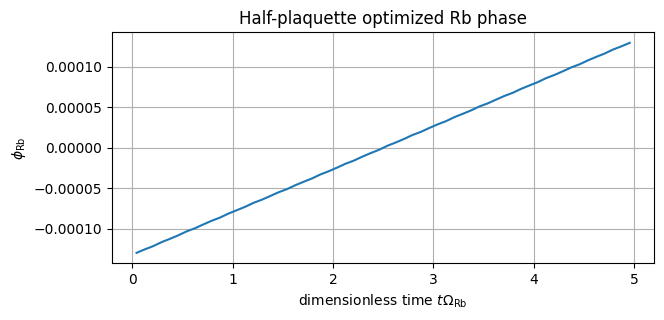

In [29]:
optimized_controls = layout.unpack(result.parameters)
time_axis = phase_sample_axis(duration=duration, samples=samples)

plt.figure(figsize=(7, 3))
plt.plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi_rb"]))
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel(r"$\phi_{\rm Rb}$")
plt.title("Half-plaquette optimized Rb phase")
plt.grid(True)
plt.show()

## Population Trace

The cell below traces selected states in the `m2_diag` block. These are representative basis-state populations for diagnostics.

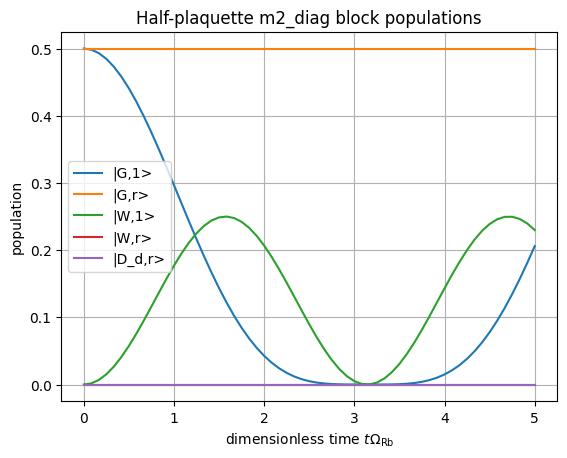

In [30]:
m2_block = next(block for block in problem.blocks if block.name == "m2_diag")
m2_controls = layout.unpack(result.parameters)

population_trace = trace_populations(
    block=m2_block,
    control_values=m2_controls,
    duration=duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(3, 0, "1"),
        "|G,r>": full_basis_state(3, 0, "r"),
        "|W,1>": full_basis_state(3, 1, "1"),
        "|W,r>": full_basis_state(3, 1, "r"),
        "|D_d,r>": full_basis_state(3, 2, "r"),
    },
)

for label, values in population_trace.populations.items():
    plt.plot(population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title("Half-plaquette m2_diag block populations")
plt.legend()
plt.grid(True)
plt.show()

## Optional Time Scan

T*Omega_Rb=8.000, infidelity=4.676534e-09
T*Omega_Rb=7.900, infidelity=4.898058e-09
T*Omega_Rb=7.800, infidelity=3.027413e-09
T*Omega_Rb=7.700, infidelity=1.243193e-09
T*Omega_Rb=7.600, infidelity=-7.660539e-13
T*Omega_Rb=7.500, infidelity=3.904330e-10
T*Omega_Rb=7.400, infidelity=3.715195e-09
T*Omega_Rb=7.300, infidelity=4.843238e-09
T*Omega_Rb=7.200, infidelity=3.176916e-09
T*Omega_Rb=7.100, infidelity=1.792452e-09
T*Omega_Rb=7.000, infidelity=7.107270e-11
T*Omega_Rb=6.900, infidelity=1.525984e-09
T*Omega_Rb=6.800, infidelity=3.156033e-09
T*Omega_Rb=6.700, infidelity=4.798001e-09
T*Omega_Rb=6.600, infidelity=5.102168e-09
T*Omega_Rb=6.500, infidelity=1.743813e-09
T*Omega_Rb=6.400, infidelity=1.915668e-11
T*Omega_Rb=6.300, infidelity=1.486903e-09
T*Omega_Rb=6.200, infidelity=8.644801e-04
T*Omega_Rb=6.100, infidelity=4.182904e-03
T*Omega_Rb=6.000, infidelity=9.957556e-03


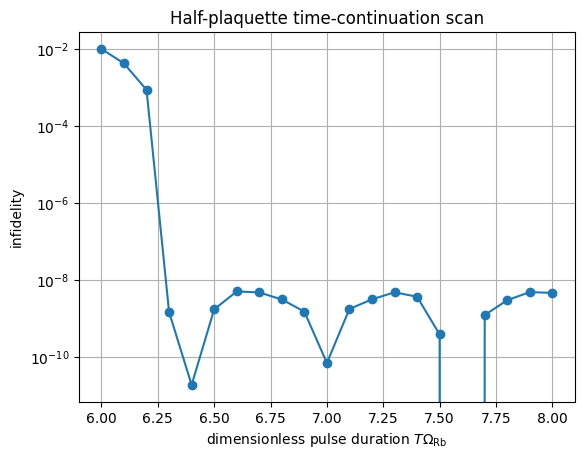

In [31]:
scan_settings = TimeScanSettings(
    start_duration=8.0,
    stop_duration=6.0,
    duration_step=0.1,
    infidelity_threshold=1e-3,
    stop_after_threshold_failure=False,
)
scan_problem = problem.with_duration(scan_settings.start_duration)
scan_points = TimeContinuationScanner(scan_problem, scan_settings).scan(initial_parameters)

durations = np.array([point.duration for point in scan_points], dtype=np.float64)
infidelities = np.array([point.result.infidelity for point in scan_points], dtype=np.float64)
order = np.argsort(durations)

for duration_value, infidelity_value in zip(durations, infidelities, strict=True):
    print(f"T*Omega_Rb={duration_value:.3f}, infidelity={infidelity_value:.6e}")

plt.semilogy(durations[order], infidelities[order], marker="o")
plt.xlabel(r"dimensionless pulse duration $T\Omega_{\rm Rb}$")
plt.ylabel("infidelity")
plt.title("Half-plaquette time-continuation scan")
plt.grid(True)
plt.show()

## Last Scan Point Diagnostics

The cells below inspect the final point returned by the continuation scan.

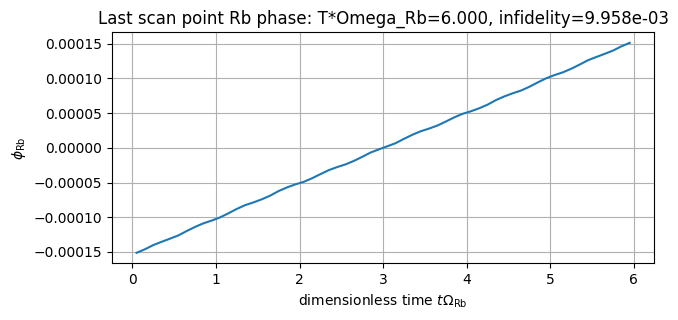

In [32]:
last_scan_point = scan_points[-1]
last_scan_controls = layout.unpack(last_scan_point.result.parameters)
last_scan_time_axis = phase_sample_axis(duration=last_scan_point.duration, samples=samples)

plt.figure(figsize=(7, 3))
plt.plot(last_scan_time_axis, unwrap_phase_profile(last_scan_controls.time_controls["phi_rb"]))
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel(r"$\phi_{\rm Rb}$")
plt.title(
    f"Last scan point Rb phase: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}, "
    f"infidelity={last_scan_point.result.infidelity:.3e}"
)
plt.grid(True)
plt.show()

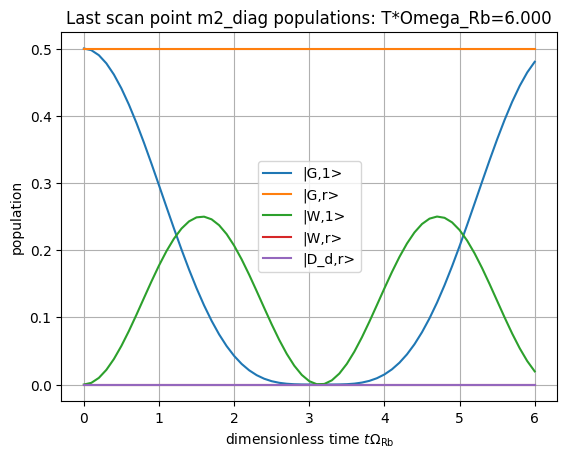

In [33]:
last_scan_m2_block = next(block for block in problem.blocks if block.name == "m2_diag")
last_scan_population_trace = trace_populations(
    block=last_scan_m2_block,
    control_values=last_scan_controls,
    duration=last_scan_point.duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(3, 0, "1"),
        "|G,r>": full_basis_state(3, 0, "r"),
        "|W,1>": full_basis_state(3, 1, "1"),
        "|W,r>": full_basis_state(3, 1, "r"),
        "|D_d,r>": full_basis_state(3, 2, "r"),
    },
)

for label, values in last_scan_population_trace.populations.items():
    plt.plot(last_scan_population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title(
    f"Last scan point m2_diag populations: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}"
)
plt.legend()
plt.grid(True)
plt.show()